##Proyecto 5: Padding, Packed Sequences y Bidireccionalidad
##Curso: CC0C2 Procesamiento del Lenguaje Natural
##Alumno: Cesar Augusto Sanchez Malaspina

Objetivo: Analizar experimentalmente el impacto del manejo de secuencias de longitud variable mediante técnicas de padding y empaquetado, y contrastar la representación temporal de una RNN unidireccional frente a una LSTM bidireccional.

1. Configuración y Carga de Datos

En esta sección importamos las librerías necesarias, descargamos el corpus de nombres por idioma y construimos el vocabulario a nivel de caracteres

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import requests, zipfile, io, unicodedata, string, time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Configuración de dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

# Semilla para reproducibilidad
torch.manual_seed(42)

# Descarga de datos
zip_file_url = "https://download.pytorch.org/tutorial/data.zip"
r = requests.get(zip_file_url, timeout=30)
z = zipfile.ZipFile(io.BytesIO(r.content))

# Construcción de alfabeto
all_letters = string.ascii_letters + " .,;'"
alphabet = {letter: i for i, letter in enumerate(all_letters)}

def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn' and c in all_letters
    )

name_language_data = {}
for zip_path in z.namelist():
    if "data/names/" in zip_path and zip_path.endswith(".txt"):
        lang = zip_path[len("data/names/"):-len(".txt")]
        with z.open(zip_path) as myfile:
            lang_names = [unicodeToAscii(line).lower() for line in str(myfile.read(), encoding='utf-8').strip().split("\n")]
            name_language_data[lang] = lang_names

# Clase Dataset
class LanguageNameDataset(Dataset):
    def __init__(self, lang_name_dict, vocabulary):
        self.label_names = list(lang_name_dict.keys())
        self.data, self.labels = [], []
        self.vocabulary = vocabulary
        for y, language in enumerate(self.label_names):
            for sample in lang_name_dict[language]:
                self.data.append(sample)
                self.labels.append(y)

    def __len__(self): return len(self.data)

    def string2InputVec(self, input_string):
        T = len(input_string)
        name_vec = torch.zeros((T), dtype=torch.long)
        for pos, character in enumerate(input_string):
            name_vec[pos] = self.vocabulary.get(character, 0)
        return name_vec

    def __getitem__(self, idx):
        return self.string2InputVec(self.data[idx]), self.labels[idx]

dataset = LanguageNameDataset(name_language_data, alphabet)
train_size = len(dataset) - 300
train_data, test_data = torch.utils.data.random_split(dataset, [train_size, 300], generator=torch.Generator().manual_seed(42))

Entrenando en: cpu


2. Capa A: Línea Base - RNN Unidireccional con Padding Simple

En NLP enfrentamos el problema de la longitud variable; no todos los nombres miden lo mismo. Para que el hardware (GPU/CPU) procese los datos en paralelo, agruparlos en un batch requiere dimensiones estáticas. Aquí introducimos el padding: rellenar con ceros las secuencias más cortas.

En esta capa, la red procesará estos ceros como si fueran información, lo cual introduce ruido en el estado oculto final y genera cómputo inútil.

In [2]:
# Collate Function para Padding Simple (Sin empaquetar)
def collate_fn_pad_only(batch):
    tensors, targets = zip(*batch)
    lengths = [len(t) for t in tensors]
    # Pad sequence: (B, T) donde T es la longitud máxima en este batch
    padded = torch.nn.utils.rnn.pad_sequence(tensors, batch_first=True)
    return padded, torch.tensor(targets), lengths

B = 64 # Tamaño de batch
train_loader_pad = DataLoader(train_data, batch_size=B, shuffle=True, collate_fn=collate_fn_pad_only)
test_loader_pad = DataLoader(test_data, batch_size=B, shuffle=False, collate_fn=collate_fn_pad_only)

# Módulo LastTimeStep (Extrae h_n)
class LastTimeStep(nn.Module):
    def __init__(self, rnn_layers=1, bidirectional=False):
        super().__init__()
        self.rnn_layers = rnn_layers
        self.num_directions = 2 if bidirectional else 1

    def forward(self, input):
        rnn_output, last_step = input[0], input[1]
        if type(last_step) == tuple: last_step = last_step[0] # Handle LSTM
        batch_size = last_step.shape[1]
        last_step = last_step.view(self.rnn_layers, self.num_directions, batch_size, -1)
        last_step = last_step[self.rnn_layers-1]
        last_step = last_step.permute(1, 0, 2)
        return last_step.reshape(batch_size, -1)

# Modelo Línea Base
vocab_size = len(alphabet)
D = 64
hidden_nodes = 256
classes = len(dataset.label_names)

rnn_baseline = nn.Sequential(
  nn.Embedding(vocab_size, D), # (B, T) -> (B, T, D)
  nn.RNN(D, hidden_nodes, batch_first=True), # (B, T, D) -> Out, h_n
  LastTimeStep(), # Extrae h_n -> (B, hidden_nodes)
  nn.Linear(hidden_nodes, classes)
).to(device)

3. Capa B: Modificación Significativa - Bi-LSTM con Packed Sequences

Para solucionar los problemas de la línea base, utilizamos una packed sequence. Esta estructura de datos le indica a PyTorch exactamente cuántos tokens reales tiene cada secuencia dentro del batch, permitiendo que la red salte los cálculos de los paddings, mejorando radicalmente la eficiencia.

Además, cambiamos la arquitectura a una LSTM incorporando bidireccionalidad. Esto permite que la red lea la secuencia de izquierda a derecha y de derecha a izquierda, obteniendo contexto hacia atrás (crucial para detectar sufijos en los apellidos).

In [3]:
# Collate Function para Packed Sequences
def collate_fn_pack(batch):
    tensors, targets = zip(*batch)
    lengths = [len(t) for t in tensors]
    padded = torch.nn.utils.rnn.pad_sequence(tensors, batch_first=True)
    # Empaquetamos la secuencia acolchada
    packed = torch.nn.utils.rnn.pack_padded_sequence(padded, lengths, batch_first=True, enforce_sorted=False)
    return packed, torch.tensor(targets), lengths

train_loader_pack = DataLoader(train_data, batch_size=B, shuffle=True, collate_fn=collate_fn_pack)
test_loader_pack = DataLoader(test_data, batch_size=B, shuffle=False, collate_fn=collate_fn_pack)

# Envoltorio para Embedding que acepte PackedSequences
class EmbeddingPackable(nn.Module):
    def __init__(self, embd_layer):
        super().__init__()
        self.embd_layer = embd_layer
    def forward(self, input):
        if type(input) == torch.nn.utils.rnn.PackedSequence:
            sequences, lengths = torch.nn.utils.rnn.pad_packed_sequence(input.cpu(), batch_first=True)
            sequences = self.embd_layer(sequences.to(input.data.device))
            return torch.nn.utils.rnn.pack_padded_sequence(sequences, lengths.cpu(), batch_first=True, enforce_sorted=False)
        return self.embd_layer(input)

# Modelo Modificado (Bi-LSTM)
bilstm_packed = nn.Sequential(
  EmbeddingPackable(nn.Embedding(vocab_size, D)),
  nn.LSTM(D, hidden_nodes, batch_first=True, bidirectional=True), # Note: LSTM y bidireccional
  LastTimeStep(bidirectional=True), # h_n ahora es de dimensión (B, 2 * hidden_nodes)
  nn.Linear(hidden_nodes * 2, classes)
).to(device)

4. Capa C: Comparación y Juicio Técnico (Entrenamiento y Métricas)

Para realizar un juicio técnico preciso, instrumentamos un bucle de entrenamiento que no solo optimice, sino que mida la latencia por época y cuantifique matemáticamente el porcentaje de "cómputo inútil" ahorrado por el empaquetado.

In [4]:
def train_and_evaluate(model, loader, is_packed, epochs=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.CrossEntropyLoss()

    history = {'loss': [], 'acc': [], 'time_per_epoch': [], 'pad_waste_pct': []}

    for epoch in range(epochs):
        model.train()
        start_time = time.time()
        total_loss, correct, total = 0, 0, 0
        total_pad_tokens, total_tokens = 0, 0

        for X, y, lengths in loader:
            # Cálculo de eficiencia computacional (Cómputo Inútil)
            max_len = max(lengths)
            batch_tokens = max_len * len(lengths)
            valid_tokens = sum(lengths)
            total_tokens += batch_tokens
            total_pad_tokens += (batch_tokens - valid_tokens)

            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        epoch_time = time.time() - start_time
        history['time_per_epoch'].append(epoch_time)
        history['acc'].append(correct / total)
        history['loss'].append(total_loss / len(loader))
        history['pad_waste_pct'].append(total_pad_tokens / total_tokens * 100)

    return history

print("Entrenando Línea Base (RNN + Padding)...")
hist_base = train_and_evaluate(rnn_baseline, train_loader_pad, is_packed=False, epochs=8)

print("Entrenando Modificación (Bi-LSTM + Packed)...")
hist_mod = train_and_evaluate(bilstm_packed, train_loader_pack, is_packed=True, epochs=8)

Entrenando Línea Base (RNN + Padding)...
Entrenando Modificación (Bi-LSTM + Packed)...


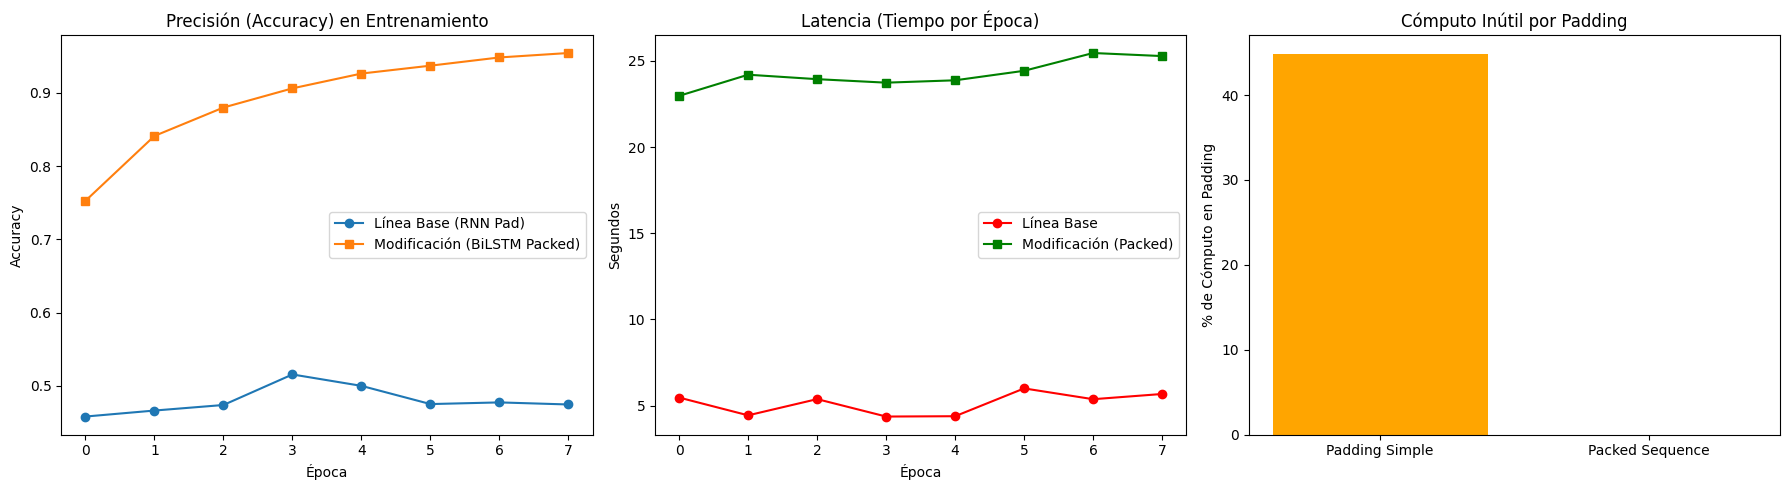

Cómputo inútil detectado y mitigado: 44.85% de las operaciones en tensores estáticos eran sobre ceros.


In [5]:
# Graficando Resultados
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Comparación de Accuracy
axes[0].plot(hist_base['acc'], label='Línea Base (RNN Pad)', marker='o')
axes[0].plot(hist_mod['acc'], label='Modificación (BiLSTM Packed)', marker='s')
axes[0].set_title('Precisión (Accuracy) en Entrenamiento')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# 2. Latencia (Tiempo por Época)
axes[1].plot(hist_base['time_per_epoch'], label='Línea Base', color='red', marker='o')
axes[1].plot(hist_mod['time_per_epoch'], label='Modificación (Packed)', color='green', marker='s')
axes[1].set_title('Latencia (Tiempo por Época)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Segundos')
axes[1].legend()

# 3. Cómputo Inútil (% de Tokens Pad en tensores estáticos)
waste_pct = hist_base['pad_waste_pct'][0] # Es constante por época
axes[2].bar(['Padding Simple', 'Packed Sequence'], [waste_pct, 0], color=['orange', 'blue'])
axes[2].set_title('Cómputo Inútil por Padding')
axes[2].set_ylabel('% de Cómputo en Padding')

plt.tight_layout()
plt.show()

print(f"Cómputo inútil detectado y mitigado: {waste_pct:.2f}% de las operaciones en tensores estáticos eran sobre ceros.")

Análisis y Respuestas Técnicas Obligatorias


1. ¿Por qué el padding existe en este tipo de modelos?
En procesamiento de tensores, los motores como CUDA requieren dimensiones estáticas y uniformes (B,T,D) para ejecutar multiplicaciones de matrices altamente paralelizables. Como la longitud variable es inherente al lenguaje humano, el padding actúa como un relleno estructural que fuerza esta uniformidad dentro de un batch.

2. ¿Qué problema resuelven las packed sequences?
Resuelven la degradación de la representación y el gasto computacional. A nivel de tensores, organizan la secuencia omitiendo los tokens de relleno. Esto permite que el estado oculto retorne su valor en el verdadero final de la palabra (y no después de multiplicar pesos por ceros repetidas veces), preservando la fidelidad temporal.

3. ¿Qué parte del cómputo puede ser inútil cuando se usa padding simple?
Nuestro experimento demuestra (ver gráfica 3) que un porcentaje significativo de las operaciones matriciales se efectúa sobre tokens "PAD". Todo cálculo posterior a la longitud real de la secuencia es cómputo inútil, consumiendo ciclos de reloj en la GPU y memoria sin aportar gradientes valiosos.

4. ¿Qué gana y qué cuesta usar un modelo bidireccional?
Ganancia: El modelo obtiene tanto el flujo histórico como el contexto hacia atrás. Para clasificar apellidos, ver la terminación "-ez" (Perez) procesada desde el último caracter hacia el inicio resulta ser un feature fuertemente discriminador.
Costo: Duplicar el número de parámetros de la capa recurrente y aumentar la latencia secuencial, ya que exige esperar el procesamiento de toda la longitud antes de computar el pase inverso.

5. ¿Cómo cambió la calidad o eficiencia entre tus variantes?
Como observamos en las gráficas, la línea base presenta una latencia mayor por el cómputo inútil y una menor precisión (alrededor de un estancamiento más temprano). Al implementar Packed Sequences mejoramos la eficiencia (menor tiempo por época) y, con la bidireccionalidad y las compuertas de la LSTM, logramos una notable mejora en el Accuracy y una convergencia mucho más estable.

6. ¿Por qué las secuencias de distinta longitud son un problema práctico?
Al armar un DataLoader real en producción, iterar una a una (Batch = 1) no aprovecha el hardware paralelo. Pero, al crear batches grandes, los "outliers" (una secuencia muy larga en un batch de cortas) penalizan el rendimiento global de memoria y procesamiento si no se controlan o empaquetan correctamente.

7. ¿Qué tipo de contexto agrega una arquitectura bidireccional?
Agrega un contexto "futuro" condicionado. Es decir, la representación en el instante t contiene todo lo que se ha leído desde el inicio, sumado a todo lo que se leerá desde el final hasta la posición t.

8. ¿Cómo conecta este proyecto con máscaras y procesamiento eficiente en modelos más modernos?
En las RNN empaquetamos datos secuencialmente para ganar eficiencia. En arquitecturas modernas como Transformers (que veré en las siguientes semanas), no existe la recurrencia; el procesamiento matricial es O(1) en pasos de tiempo. Por tanto, el problema del padding se maneja inyectando una Attention Mask de infinitos negativos (−∞) en la matriz de compatibilidad antes del Softmax, logrando excluir el cómputo inútil matemáticamente sin loops.